In [1]:
# Import necessary packages

import numpy as np # NumPy helps in numerical calculations and arrays
import matplotlib.pyplot as plt # lets us make plots and visualize our results
print(np.__version__) # tells us of the numpy version being used

1.26.4


In [2]:
# Different data types
age = 25 #int
height = 5.5 #float
human = True #bool
name = "Malindi" #string
type(age), type(height) #returns data type of variable

(int, float)

In [3]:
# Defining and initializing variables
r = 0.5 # Human idea population growth rate
K = 10 # carrying capacity
h = 1.5 # harvest rate
a = 1 # harvest saturation

In [4]:
# Defining and initializing variables
r = 0.5
K = 10
h = 1.5
a = 1 

x_0 = 6 # initial human population

farm_name = "AI-7" # farm name
viable = x_0 > 4 # is the starting population above 4?

print(viable)
print(type(viable), type(farm_name))

True
<class 'bool'> <class 'str'>


In [5]:
# Print statements
print(f"Hello my name is {name}, and I am {height:.1f} feet tall")

# Problem: Quarterly report
print(f"Farm {farm_name}: population {x_0:.2f} ({x_0/K:.0%} of capacity)")
print(f"r = {r}, K = {K}, h = {h}, a = {a}")

Hello my name is Malindi, and I am 5.5 feet tall
Farm AI-7: population 6.00 (60% of capacity)
r = 0.5, K = 10, h = 1.5, a = 1


In [6]:
# Defining functions

def growth(x, r, K):
    # Natural growth of human population
    return r*x*(1 - x/K)

def harvest(x, h, a):
    '''
    Population harvested by AI
    This shows another way in which comments can be made within a function.
    '''
    return h*x/(a + x)

def rhs(t, x, r, K, h, a):
    # Rate of population change
    return growth(x, r, K) - harvest(x, h, a)

print(rhs(0, 5, 0.5, 10, 1.5, 1))
print(rhs(0, 4, 0.5, 10, 1.5, 1))   

0.0
0.0


In [7]:
# Using numpy and defining lists and arrays

lst = [1, 2, 3]
print(type(lst))
arr = np.array([1, 2, 3])
print(type(arr)) 

arr2 = np.array(lst)
print(type(arr2)) # convert list to array
 
print(np.sort(arr))  # sort the list
print(arr.sum()) # sum the elements of the array

<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[1 2 3]
6


In [8]:
# Problem: Multiple farms

pens_list = [4.2, 7.1, 1.3, 9.8, 5.5] # define the list
pens = np.array(pens_list) # convert list to array

# Observe the difference below!
print(pens_list * 2)  
print(pens * 2)       

print(np.sort(pens)[::-1])   
print(f"Sum {pens.sum():.2f}, max {pens.max()}")   
x = np.linspace(0, 12, 121)
rates = rhs(0, x, 0.5, 10, 1.5, 1)
print(rates.shape)     # (121,)

[4.2, 7.1, 1.3, 9.8, 5.5, 4.2, 7.1, 1.3, 9.8, 5.5]
[ 8.4 14.2  2.6 19.6 11. ]
[9.8 7.1 5.5 4.2 1.3]
Sum 27.90, max 9.8
(121,)


In [9]:
# Using if/else statements

if age < 13:
    status = "child"
elif age < 18:
    status = "teenager"
else:
    status = "adult"

status

'adult'

In [10]:
# Problem: Farm triage

def classify(x):
    if x < 4:
        return "doomed"
    elif x <= K:
        return "viable"
    else:
        return "overcrowded"

# classify for several values of population
print([classify(p) for p in [2, 4, 6, 12]])

def trend(x):
    return "growing" if rhs(0, x, r, K, h, a) > 0 else "shrinking"

trend(x = 4.5)

['doomed', 'viable', 'viable', 'overcrowded']


'growing'

In [11]:
# Problem: Simulate by Predicting the future

dt = 0.1 # time step 
x = 6.0
for n in range(500):
    x = x + dt*rhs(0, x, r, K, h, a)
print(f"Day 50 population: {x:.2f}")   # 5.06

x, t = 3.0, 0.0
while x > 0.1:
    # Euler method
    x = x + dt*rhs(0, x, r, K, h, a)
    t = t + dt
print(f"Collapse at t = {t:.1f} days")   # 16.0

Day 50 population: 5.06
Collapse at t = 16.0 days


In [12]:
# Perform basic linear algebra

A = np.array([[1, 2], [3, 4]])
v = np.array([1, 1])
 
print(A @ v)       # [3 7]
print(np.linalg.solve(A, v))
vals, vecs = np.linalg.eig(A)
print('eigen_vals', vals)
print('eigen_vecs', vecs)

[3 7]
[-1.  1.]
eigen_vals [-0.37228132  5.37228132]
eigen_vecs [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [13]:
# Problem: Inter-Farm Traffic

A = np.array([[-0.4, 0.1], [0.2, -0.3]])
b = np.array([1, 1])
print(A @ np.array([5, 3]))   
vals, vecs = np.linalg.eig(A)
print(vals)                   
p = np.linalg.solve(A, -b)
print(p)                    
print(A @ p + b)                

[-1.7  0.1]
[-0.5 -0.2]
[4. 6.]
[0.00000000e+00 2.22044605e-16]


In [14]:
#Solving ODEs with SciPy

from scipy.integrate import solve_ivp
 
sol = solve_ivp(rhs, (0, 50), [6],
    args=(r, K, h, a),
    t_eval=np.linspace(0, 50, 500))
 
# sol.t
# sol.y[0]

In [15]:
# Problem: Let SciPy run the farm

t_eval = np.linspace(0, 50, 500)
sol = solve_ivp(rhs, (0, 50), [6], args=(r, K, h, a), t_eval=t_eval)
print(sol.y[0][-1])             

for x_0 in [1, 3, 4.5, 6, 9]:
    sol = solve_ivp(rhs, (0, 50), [x_0], args=(r, K, h, a), t_eval=t_eval)
    print(x_0, round(sol.y[0][-1], 2))

5.067532057151892
1 0.0
3 0.0
4.5 4.89
6 5.07
9 5.11


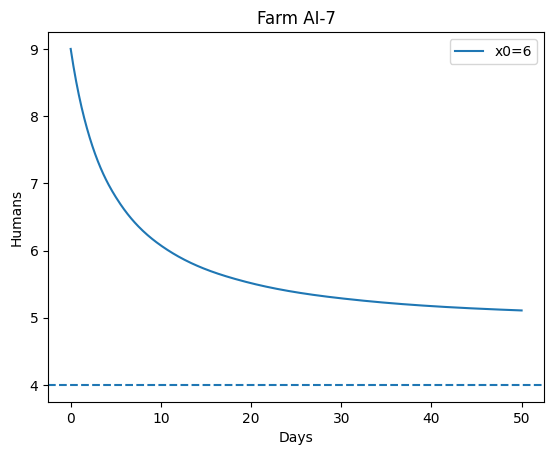

In [16]:
# Plotting with matplotlib

plt.plot(sol.t, sol.y[0], label="x0=6")
plt.axhline(4, ls="--")
plt.xlabel("Days")
plt.ylabel("Humans")
plt.title("Farm AI-7")
plt.legend()
plt.show()

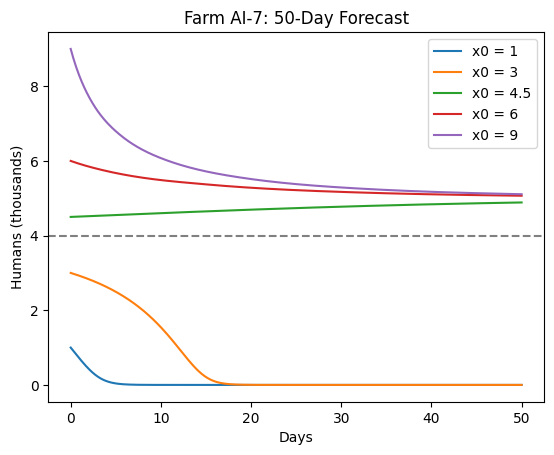

In [17]:
# Problem: Present Evidence

t_eval = np.linspace(0, 50, 500)
plt.figure()
for x_0 in [1, 3, 4.5, 6, 9]:
    sol = solve_ivp(rhs, (0, 50), [x_0], args=(r, K, h, a), t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f"x0 = {x_0}")
plt.axhline(4, ls="--", color="gray")
plt.xlabel("Days"); plt.ylabel("Humans (thousands)")
plt.title("Farm AI-7: 50-Day Forecast")
plt.legend()
plt.show()

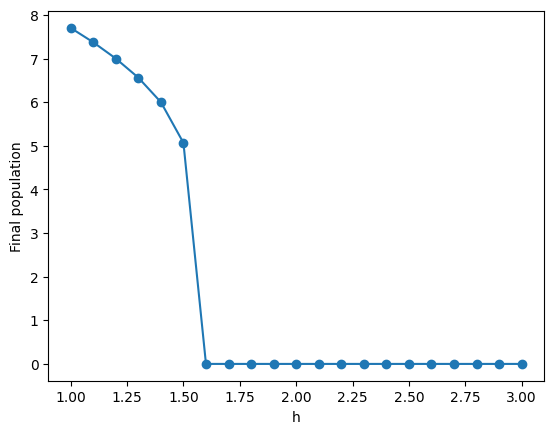

In [18]:
# Bonus Problem

hs = np.linspace(1, 3, 21)
finals = []
for hh in hs:
    sol = solve_ivp(rhs, (0, 50), [6], args=(r, K, hh, a), t_eval=np.linspace(0, 50, 500))
    finals.append(sol.y[0][-1])
plt.plot(hs, finals, "o-"); plt.xlabel("h"); plt.ylabel("Final population"); plt.show()